# Statistics Concepts in Python
Reference notebook covering probability distributions, expected value, visualization, and the law of large numbers.

---
## 1. Probability Distributions

A **probability distribution** describes all possible outcomes of something and how likely each one is.

- Probability is expressed between 0 (impossible) and 1 (certain)
- A distribution is a complete map of outcomes and their probabilities

**Example:** Rolling a six-sided die — outcomes are 1–6, each with probability 1/6 ≈ 0.167

**Two types:**
- **Discrete** — countable, distinct values (e.g. die rolls — you can't roll 2.7)
- **Continuous** — any value within a range (e.g. height, temperature)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the distribution of a fair six-sided die
outcomes = [1, 2, 3, 4, 5, 6]
probability = 1/6  # same for all outcomes

print("Outcomes:", outcomes)
print(f"Probability of each outcome: {probability:.4f}")
print(f"Sum of all probabilities: {probability * len(outcomes):.1f}")

---
## 2. Discrete Uniform Distribution

**Uniform** means every outcome has the same probability.

- A fair die is the classic example — no outcome is favored
- If the die were loaded (e.g. 6 appears more often), it would **no longer** be uniform

In [ ]:
# Uniform distribution — all probabilities equal
outcomes = [1, 2, 3, 4, 5, 6]
uniform_probs = [1/6] * 6

# Non-uniform distribution — loaded die (6 appears more often)
loaded_probs = [0.1, 0.1, 0.1, 0.1, 0.1, 0.5]

print("Uniform probabilities:", [round(p, 3) for p in uniform_probs])
print("Loaded die probabilities:", loaded_probs)
print(f"Sum check (uniform): {sum(uniform_probs):.1f}")
print(f"Sum check (loaded): {sum(loaded_probs):.1f}")

---
## 3. Expected Value

The **expected value** is the long-run average if you repeated something many times.

- Not what you expect on any single attempt
- The average you'd converge to over many attempts

**Formula:** Multiply each outcome by its probability, then sum everything up

$$E(X) = \sum x_i \cdot P(x_i)$$

For a fair die: (1×1/6) + (2×1/6) + (3×1/6) + (4×1/6) + (5×1/6) + (6×1/6) = **3.5**

> You'll never roll 3.5 — but average 1000 rolls and you'll land very close to it.

In [ ]:
outcomes = [1, 2, 3, 4, 5, 6]
probability = 1/6

# Calculate expected value
expected_value = sum(x * probability for x in outcomes)
print(f"Expected value of a fair die: {expected_value}")

# Same result using numpy
ev_numpy = np.dot(outcomes, [probability] * 6)
print(f"Expected value (numpy): {ev_numpy}")

---
## 4. Visualizing Distributions

Two main tools:

- **Bar plots** — for discrete distributions. Each bar is an outcome, height is its probability. Shows the theoretical shape.
- **Histograms** — for actual sample data. Shows how often each value appeared. More samples = shape closer to the true distribution.

In [ ]:
outcomes = [1, 2, 3, 4, 5, 6]
probabilities = [1/6] * 6

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot — theoretical distribution
axes[0].bar(outcomes, probabilities, color='steelblue', edgecolor='black')
axes[0].set_title('Theoretical Distribution (Bar Plot)')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Probability')
axes[0].set_ylim(0, 0.3)

# Histogram — sample data
samples = np.random.choice(outcomes, size=1000)
axes[1].hist(samples, bins=6, edgecolor='black', color='coral', density=True)
axes[1].set_title('Sample Distribution (Histogram, n=1000)')
axes[1].set_xlabel('Outcome')
axes[1].set_ylabel('Frequency (normalized)')

plt.tight_layout()
plt.show()

---
## 5. Sampling and the Law of Large Numbers

**Sampling** means drawing random outcomes from a distribution — simulating die rolls, for example.

The **Law of Large Numbers** states:
> The more samples you take, the closer your sample mean gets to the theoretical expected value.

- With 10 rolls you might get 4.2
- With 10,000 rolls you'll be very close to 3.5
- The randomness averages out as sample size grows

In [6]:
import numpy as np

# Law of large numbers — sample mean converges to expected value
sample_sizes = [10, 100, 1000, 10000]

print(f"{'Sample Size':<15} {'Sample Mean':<15} {'Difference from 3.5'}")
print("-" * 50)

for n in sample_sizes:
    samples = np.random.choice([1, 2, 3, 4, 5, 6], size=n)
    mean = samples.mean()
    diff = abs(mean - 3.5)
    print(f"{n:<15} {mean:<15.4f} {diff:.4f}")

Sample Size     Sample Mean     Difference from 3.5
--------------------------------------------------
10              3.7000          0.2000
100             3.6000          0.1000
1000            3.4890          0.0110
10000           3.5114          0.0114


In [ ]:
import numpy as np

# Visualize convergence — running mean approaching 3.5
rolls = np.random.choice([1, 2, 3, 4, 5, 6], size=1000)
running_mean = np.cumsum(rolls) / np.arange(1, len(rolls) + 1)

plt.figure(figsize=(10, 4))
plt.plot(running_mean, color='steelblue', label='Running Mean')
plt.axhline(y=3.5, color='red', linestyle='--', label='Expected Value (3.5)')
plt.title('Law of Large Numbers — Running Mean Converging to 3.5')
plt.xlabel('Number of Rolls')
plt.ylabel('Running Mean')
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'np' is not defined

---
## Summary — How These Concepts Connect

| Concept | What it does |
|---|---|
| **Distribution** | Defines all possible outcomes and their probabilities |
| **Discrete Uniform** | Special case where all outcomes have equal probability |
| **Expected Value** | Summarizes the distribution with one number (long-run average) |
| **Visualization** | Bar plots for theory, histograms for samples |
| **Sampling** | Simulates real draws from the distribution |
| **Law of Large Numbers** | Explains why larger samples are more reliable |

> The thread: a distribution maps outcomes → expected value summarizes it → visualization shows its shape → sampling simulates it → law of large numbers explains why it stabilizes.

# Continuous Uniform Distributions (Amir's Backup Scenario)

### 1. Scenario Overview

* **The Problem:** A company sales software backs up automatically exactly every 30 minutes. Amir updates client records at completely random times and wants to know how long he must wait for his data to be backed up.
* **The Distribution:** Because any arrival time within the 30-minute window is equally likely, this scenario is modeled using a Continuous Uniform Distribution.

---

### 2. Core Statistical Concepts & Mathematical Expressions

#### A. Distribution Boundaries
A uniform distribution is defined by its minimum possible outcome ($a$) and maximum possible outcome ($b$).
* **Minimum Time** ($a$): 0 minutes (Amir arrives exactly as a backup begins).
* **Maximum Time** ($b$): 30 minutes (Amir arrives exactly after a backup ends).
* **Total Range (Width):** $$b - a = 30 - 0 = 30 \text{ minutes}$$

#### B. Probability Density Function (PDF)
The PDF represents the height of the distribution graph. For a continuous uniform distribution, the height is constant (flat) because every outcome is equally likely. The total area under the curve must equal 1 (representing 100% total probability).

$$\text{Height (Density)} = \frac{1}{b - a} = \frac{1}{30} \approx 0.0333$$

* The density remains exactly 0.0333 from minute 0 to minute 30, and is 0 everywhere else.

#### C. Calculating Probabilities using the Cumulative Distribution Function (CDF)
The CDF calculates the probability that an event is less than or equal to a specific target value ($x$). Geometrically, this calculates the area of a rectangle from the minimum boundary ($a$) up to your target value ($x$).

* **Probability Less Than a Value** $P(X < x)$:

$$P(X < x) = \text{CDF}(x)$$

> *Example for* $P(X < 5)$: 
> $$\frac{5 - 0}{30} = \frac{5}{30} \approx 16.67\%$$

* **Probability Greater Than a Value** $P(X > x)$:
Since total probability is 1, the probability of waiting more than a certain time is the complement of waiting less than that time.

$$P(X > x) = 1 - P(X \le x) = 1 - \text{CDF}(x)$$

> *Note: Alternatively, you can use the Survival Function (SF) which natively calculates greater-than values:* $\text{SF}(x)$.

* **Probability Between Two Values** $P(x_1 < X < x_2)$:
To find the probability between a lower bound ($x_1$) and an upper bound ($x_2$), calculate the total area up to the upper bound and subtract the unwanted lower area.

$$P(x_1 < X < x_2) = \text{CDF}(x_2) - \text{CDF}(x_1)$$

---

### 3. Python Implementation Mapping

When translating these concepts into Python using the `scipy.stats.uniform` module, the parameters map as follows:

* `loc`: The minimum value of the distribution ($a$). In this case, **0**.
* `scale`: The total width or range of the distribution ($b - a$). In this case, **30**.

In [ ]:
from scipy.stats import uniform

# =====================================================================
# 1. Define Distribution Parameters
# =====================================================================
# Min and max wait times for back-up that happens every 30 min
min_time = 0
max_time = 30

# In scipy.stats.uniform:
# 'loc' is the start point (min_time)
# 'scale' is the width/range of the distribution (max_time - min_time)
dist_loc = min_time
dist_scale = max_time - min_time  # 30 - 0 = 30


# =====================================================================
# 2. Probability Calculations
# =====================================================================

# Question A: Calculate probability of waiting LESS than 5 mins
# We use the Cumulative Distribution Function (cdf)
prob_less_than_5 = uniform.cdf(5, loc=dist_loc, scale=dist_scale)


# Question B: Calculate probability of waiting MORE than 5 mins
# Method 1: Complement Rule (1 - cdf)
prob_greater_than_5_m1 = 1 - uniform.cdf(5, loc=dist_loc, scale=dist_scale)

# Method 2: Survival Function (sf), which is optimized for P(X > x)
prob_greater_than_5_m2 = uniform.sf(5, loc=dist_loc, scale=dist_scale)


# Question C: Calculate probability of waiting BETWEEN 10 and 20 mins
# We subtract the lower cdf from the upper cdf
prob_between_10_and_20 = uniform.cdf(20, loc=dist_loc, scale=dist_scale) - \
                         uniform.cdf(10, loc=dist_loc, scale=dist_scale)


# =====================================================================
# 3. Display Results
# =====================================================================
print("--- Amir's Backup Wait Time Analysis ---")
print(f"Probability of waiting < 5 mins:       {prob_less_than_5:.4f} ({prob_less_than_5 * 100:.2f}%)")
print(f"Probability of waiting > 5 mins (m1):  {prob_greater_than_5_m1:.4f} ({prob_greater_than_5_m1 * 100:.2f}%)")
print(f"Probability of waiting > 5 mins (m2):  {prob_greater_than_5_m2:.4f} ({prob_greater_than_5_m2 * 100:.2f}%)")
print(f"Probability of waiting 10-20 mins:     {prob_between_10_and_20:.4f} ({prob_between_10_and_20 * 100:.2f}%)")

--- Amir's Backup Wait Time Analysis ---
Probability of waiting < 5 mins:       0.1667 (16.67%)
Probability of waiting > 5 mins (m1):  0.8333 (83.33%)
Probability of waiting > 5 mins (m2):  0.8333 (83.33%)
Probability of waiting 10-20 mins:     0.3333 (33.33%)


# Simulating Data with Random Variate Samples (RVS)

### 1. The Core Concept: What is `rvs`?
* **RVS (Random Variate Sample):** While functions like the CDF calculate exact, theoretical probabilities, `rvs` is used to **simulate data**. It acts as a data generator, picking random values that strictly follow the rules of a specific probability distribution.
* **The Simulation:** By generating 1,000 random wait times between 0 and 30 minutes, we are essentially running a simulation as if we observed Amir arriving from his sales meetings 1,000 different times.

### 2. Logical Breakdown of the Process

**Step 1: Setting the Seed for Reproducibility**
* Computers cannot generate truly random numbers; they use math formulas to create "pseudo-random" numbers starting from a baseline value called a seed. 
* By setting a specific seed (e.g., `334`), we force the computer to generate the exact same sequence of "random" numbers every time the script runs. This ensures our data is reproducible for other developers or instructors.

**Step 2: Simulating the Data**
* The `uniform.rvs()` function requires the distribution boundaries and the desired output size. We pass in the minimum time (`loc = 0`), the total width of the window (`scale = 30`), and the number of experiments to simulate (`size = 1000`).

**Step 3: Visualizing with a Histogram**
* A histogram takes our 1,000 continuous data points and groups them into intervals (bins). 
* Because our data follows a **uniform distribution**, every time interval has an equal chance of occurring. Therefore, the resulting histogram will look relatively flat and rectangular across the 0 to 30 axis, perfectly mirroring the flat Probability Density Function (PDF) of a continuous uniform distribution.

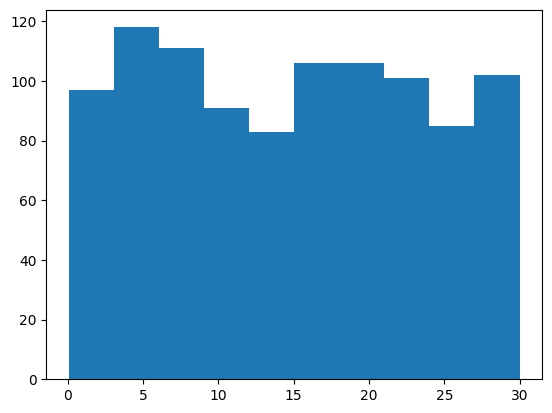

In [4]:
import numpy as np
import matplotlib.pyplot as plt
# Set random seed to 334
np.random.seed(334)

# Import uniform
from scipy.stats import uniform

# Generate 1000 wait times between 0 and 30 mins
wait_times = uniform.rvs(0, 30, size=1000)

# Create a histogram of simulated times and show plot
plt.hist(wait_times)
plt.show()

# The Binomial Distribution

### 1. The Core Concept
* **Discrete vs. Continuous:** The binomial distribution marks a shift from measuring *continuous* data (like time or distance) to counting *discrete* data (like the number of whole successes).
* **The Definition:** It models the probability of achieving exactly $k$ "successes" in a fixed number of trials.

#### The Four Strict Rules of a Binomial Scenario
For a dataset to be binomial, it must pass these four checks:
1. **Binary Outcomes:** There are only two possible outcomes per trial (e.g., Success/Failure, Yes/No, Heads/Tails).
2. **Fixed Trials ($n$):** The total number of attempts or observations is set in advance.
3. **Independent Trials:** The outcome of one trial has absolutely no effect on the next.
4. **Constant Probability ($p$):** The probability of success remains exactly the same for every single trial.

---

### 2. Mathematical Parameters & Formulas

A binomial distribution does not use minimum and maximum boundaries. Instead, it is completely defined by two parameters:
* **$n$**: The total number of trials.
* **$p$**: The probability of success on any single trial.

#### Probability Mass Function (PMF)
Because binomial data is discrete, we use a Probability Mass Function (PMF) instead of a Density Function (PDF). The PMF calculates the exact probability of getting exactly $k$ successes.

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

---

### 3. Python Implementation Mapping (`scipy.stats.binom`)

When translating binomial scenarios into Python, we use the `binom` module. The standard arguments are `k` (target successes), `n` (total trials), and `p` (probability of success).

#### A. Finding EXACT Probabilities
Use the Probability Mass Function (`pmf`) when the question asks for an exact number of successes (e.g., "exactly 5 sales").

$$P(X = 5)$$
```python
from scipy.stats import binom
prob_exact = binom.pmf(k=5, n=10, p=0.5)
```

#### B. Finding CUMULATIVE Probabilities (Less than or Equal to)
Use the Cumulative Distribution Function (`cdf`) when the question asks for a range up to a certain point (e.g., "5 or fewer sales", "at most 5 sales").

$$P(X \le 5)$$

```python
prob_less_equal = binom.cdf(k=5, n=10, p=0.5)
```

#### C. Simulating Binomial Data
Use Random Variate Samples (`rvs`) to simulate running the entire set of trials multiple times (e.g., "Simulate 10 coin flips, and do that experiment 1,000 times").

```python
# size = number of experiments to simulate
simulated_data = binom.rvs(n=10, p=0.5, size=1000)
```

### 4. Mapping Timeframes to Binomial Parameters (`n` vs. `size`)

When simulating real-world scenarios, it is crucial not to confuse the size of a single experiment (`n`) with the number of times you run the experiment (`size`).

**Scenario:** Amir works on 3 deals per week. He wins 30% of them. 
* **The Trial (`n`):** The number of opportunities in a single timeframe. Since he works on 3 deals in a single week, `n = 3`. 
* **The Probability (`p`):** The win rate. `p = 0.3`.

**Using `size` to simulate time:**
The `size` parameter dictates how many "weeks" we want to simulate. 
* **Simulate 1 week:** `size = 1` (Output: `[1]` -> He won 1 deal this week)
* **Simulate 1 month (4 weeks):** `size = 4` (Output: `[1, 0, 2, 1]` -> The number of deals won each week for 4 weeks)
* **Simulate 1 year (52 weeks):** `size = 52` (Output: An array of 52 numbers showing his weekly performance for the whole year)

### 5. Practical Exercise: Simulating Sales Deals

**The Scenario:** Amir works on exactly 3 deals per week. Historically, he wins 30% of the deals he works on. Each deal has a binary outcome (Won/Lost). We use the `binom.rvs()` function to simulate his performance over different timeframes.

* **Trials (`n`):** The number of opportunities in a single timeframe. 
* **Probability (`p`):** The constant win rate (30% or 0.3).
* **Simulations (`size`):** The number of timeframes we want to generate data for.

#### A. Simulating a Single Deal
To see the outcome of just one specific deal, we set the trials to 1 and the size to 1.
* `binom.rvs(n=1, p=0.3, size=1)`
* Output: `[1]` (Won) or `[0]` (Lost)

#### B. Simulating One Week
To simulate a single standard week (where Amir works on 3 deals), we set the trials to 3, but keep the size at 1 because we only want one week's worth of data.
* `binom.rvs(n=3, p=0.3, size=1)`
* Output: e.g., `[2]` (He won 2 out of 3 deals this week)

#### C. Simulating a Full Year
To simulate an entire year to analyze long-term performance, we keep the trials at 3 (deals per week) and set the size to 52 (weeks in a year). 
* `deals = binom.rvs(n=3, p=0.3, size=52)`
* Output: An array of 52 numbers. By calling `.mean()` on this array, we can find the average number of deals Amir won per week over the simulated year.

In [1]:
import numpy as np
from scipy.stats import binom

print("--- Amir's Sales Simulation ---")

# Set random seed for reproducibility
np.random.seed(10)

# 1. Simulate 1 single deal (n=1, p=0.3)
single_deal = binom.rvs(n=1, p=0.3, size=1)
print(f"Outcome of a single deal: {single_deal}")

# 2. Simulate 1 week of 3 deals (n=3, p=0.3)
single_week = binom.rvs(n=3, p=0.3, size=1)
print(f"Deals won in a single week: {single_week}")

# 3. Simulate 52 weeks (1 year) of 3 deals
deals_year = binom.rvs(n=3, p=0.3, size=52)
print(f"\nDeals won each week over a year:\n{deals_year}")

# Calculate and print the mean deals won per week over the simulated year
mean_deals_won = deals_year.mean()
print(f"\nAverage deals won per week: {mean_deals_won:.2f}")

--- Amir's Sales Simulation ---
Outcome of a single deal: [1]
Deals won in a single week: [0]

Deals won each week over a year:
[1 1 1 0 0 1 0 0 1 2 0 1 2 1 1 0 2 1 1 0 1 1 1 1 1 1 1 1 2 1 2 0 0 0 0 2 0
 1 1 2 0 2 1 1 0 2 0 0 1 0 2 0]

Average deals won per week: 0.85


# Study Notes: Why We Simulate Data in the Real World

While mathematical formulas (like the PDF, PMF, or CDF) calculate exact **theoretical probabilities**, the real world is rarely that clean. In professional data science, we rely heavily on **data simulation** (using functions like `rvs`) to solve problems that are too complex, risky, or expensive to figure out using standard math.

Here are the four primary reasons professionals use simulation:

### 1. The Math is Too Complex (or Impossible)
When dealing with a single variable, calculating probabilities is easy. But real-world systems (like global supply chains) involve dozens of interacting variables: machine failure rates, weather delays, economic fluctuations, and human error. 
* Writing a single mathematical equation to perfectly account for all these interactions is virtually impossible. 
* Instead, analysts program the "rules" of the system into a computer, run 10,000 simulations, and observe the results.

### 2. To Understand Risk and Uncertainty (Monte Carlo Simulations)
In business, relying on a single "average" expected outcome is dangerous. 
* If a business projects $500,000 in revenue based on an *average* win rate, they are completely blind to risk. 
* **Simulation reveals the range of possibilities.** By simulating 1,000 different years of sales, a company can see their worst-case scenarios (e.g., 10th percentile: $350k) and best-case scenarios (e.g., 90th percentile: $700k). This is exactly how hedge funds and insurance companies calculate risk.

### 3. To Test "What-If" Scenarios Safely and Cheaply
Simulation acts as a risk-free digital sandbox. 
* You cannot crash a real airplane 1,000 times to test a new wing design, nor can you completely reorganize a hospital emergency room every week to see which layout reduces patient wait times.
* Engineers and planners simulate thousands of layouts and stress-test them digitally to find the best solution before spending any money or risking human safety.

### 4. Overcoming a Lack of Historical Data (Synthetic Data)
When launching a brand-new product or entering a new market, there is zero historical data to base decisions on. 
* You cannot train an AI model or forecast revenue on nothing. 
* By simulating data based on reasonable assumptions (like we did with the continuous uniform distribution), analysts can create **"synthetic data"** to test software, train machine learning models, and create preliminary business plans until real data is available.

# Study Notes: Calculating Binomial Probabilities

### 1. Scenario Overview
* **The Problem:** Amir works on exactly 3 deals per week ($n = 3$). He has a historical win rate of 30% ($p = 0.3$).
* **The Distribution:** Because we are counting discrete successes (won deals) out of a fixed number of trials with a constant probability, this is modeled using a **Binomial Distribution**.

### 2. Calculating Probabilities (`scipy.stats.binom`)

* **Exact Probabilities ($P(X = k)$):** Use the Probability Mass Function (`pmf`).
    * *Example:* Probability of closing exactly 3 deals.
    * `binom.pmf(k=3, n=3, p=0.3)`

* **Cumulative Probabilities ($P(X \le k)$):** Use the Cumulative Distribution Function (`cdf`).
    * *Example:* Probability of closing 1 or fewer deals.
    * `binom.cdf(k=1, n=3, p=0.3)`

* **Greater-Than Probabilities ($P(X > k)$):** Subtract the `cdf` from 1. 
    * *Example:* Probability of closing strictly more than 1 deal.
    * `1 - binom.cdf(k=1, n=3, p=0.3)`
    * *(Note: You can also use the Survival Function: `binom.sf(k=1, n=3, p=0.3)`)*

---

# The Ultimate Guide: PMF vs. PDF vs. CDF vs. RVS

When using `scipy.stats`, choosing the right function comes down to asking two questions: 
1. Am I calculating pure math or running a simulation?
2. Is my data discrete (counted) or continuous (measured)?

### 1. The "Exact" Functions: PMF vs. PDF
These functions answer the question: *"What is the probability/density exactly at this specific point?"*

* **PMF (Probability Mass Function):** Use this for **Discrete** data (like the Binomial distribution). It gives you the exact probability of a whole number outcome (e.g., getting exactly 3 heads).
    * *Code:* `binom.pmf()`
* **PDF (Probability Density Function):** Use this for **Continuous** data (like the Uniform or Normal distribution). Because continuous numbers have infinite decimal places, the PDF gives you the "height" of the curve at that point, not a direct probability.
    * *Code:* `uniform.pdf()`

### 2. The "Range" Function: CDF
This function answers the question: *"What is the total probability of everything up to and including this point?"*

* **CDF (Cumulative Distribution Function):** Use this for **both** discrete and continuous data when you need a "less than or equal to" probability. It calculates the total accumulated area under the curve from the absolute minimum up to your target value. 
    * *Discrete Code:* `binom.cdf()`
    * *Continuous Code:* `uniform.cdf()`
    * *Pro-Tip:* To find "greater than", always use $1 - \text{CDF}$. 

### 3. The "Simulation" Function: RVS
This function abandons theoretical math and runs a virtual experiment.

* **RVS (Random Variate Sample):** Use this when you want to generate a list of random, artificial data points that follow the rules of your chosen distribution. 
    * *Use Case:* "Simulate Amir working for 52 weeks and tell me how many deals he closed each week."
    * *Code:* `binom.rvs(size=52)` or `uniform.rvs(size=52)`

In [3]:
from scipy.stats import binom

print("--- Amir's Weekly Deal Probabilities ---")
print("Scenario: 3 deals per week, 30% win rate (n=3, p=0.3)\n")

# 1. Probability of closing EXACTLY 3 out of 3 deals
prob_3 = binom.pmf(k=3, n=3, p=0.3)
print(f"Probability of closing exactly 3 deals: {prob_3:.4f} ({prob_3 * 100:.2f}%)")

# 2. Probability of closing 1 OR FEWER deals (<= 1)
prob_less_than_or_equal_1 = binom.cdf(k=1, n=3, p=0.3)
print(f"Probability of closing <= 1 deal:       {prob_less_than_or_equal_1:.4f} ({prob_less_than_or_equal_1 * 100:.2f}%)")

# 3. Probability of closing MORE THAN 1 deal (> 1)
# Calculated as 1 minus the probability of closing 1 or fewer
prob_greater_than_1 = 1 - binom.cdf(k=1, n=3, p=0.3)
print(f"Probability of closing > 1 deal:        {prob_greater_than_1:.4f} ({prob_greater_than_1 * 100:.2f}%)")

--- Amir's Weekly Deal Probabilities ---
Scenario: 3 deals per week, 30% win rate (n=3, p=0.3)

Probability of closing exactly 3 deals: 0.0270 (2.70%)
Probability of closing <= 1 deal:       0.7840 (78.40%)
Probability of closing > 1 deal:        0.2160 (21.60%)


# Study Notes: Expected Value in a Binomial Distribution

### What is Expected Value?
The **Expected Value** (often written as $E[X]$ or the mean, $\mu$) tells you the long-term average outcome of a random variable if you were to repeat the experiment many, many times. 

Even though Amir cannot physically win "0.9" of a deal in a single week, if he works on 3 deals a week for 10 years, he will average exactly 0.9 deals won per week.

### The Formula
For a binomial distribution, the expected value is incredibly simple to calculate. You do not need a special `scipy.stats` function; you just multiply the number of trials ($n$) by the probability of success ($p$).

$$E[X] = n \times p$$

**Example:**
If Amir works on 3 deals ($n = 3$) and has a 35% win rate ($p = 0.35$):
* Expected Value = $3 \times 0.35 = 1.05$ deals won per week.

In [4]:
# Expected number won with 30% win rate
won_30pct = 3 * 0.3
print(won_30pct)

# Expected number won with 25% win rate
won_25pct = 3 * 0.25
print(won_25pct)

# Expected number won with 35% win rate
won_35pct = 3 * 0.35
print(won_35pct)

0.8999999999999999
0.75
1.0499999999999998


# Refresher: The Core Concepts of Probability Distributions

### 1. What is a Distribution?
A probability distribution is simply a mathematical "map" of a random event. It does two things:
1. It lists **every possible outcome** that could happen.
2. It tells you **how likely** each outcome is to occur. 

If you graph a distribution, the shape of the data visually tells you where the most likely outcomes are clustered and where the rare, extreme outcomes live.

### 2. Why are there different types of distributions?
There are different types of distributions because the universe produces different kinds of data! The two main categories you have learned so far are:

* **Continuous Data (Measuring):** Things that can be broken down into infinite decimals (like time, weight, or distance). 
* **Discrete Data (Counting):** Things that can only be whole numbers (like the number of sales won, or heads flipped). 

You cannot use the same math to predict a continuous wait time that you use to count whole sales deals. Hence, different distributions!

---

### 3. The Distributions covered so far

#### A. The Continuous Uniform Distribution
* **The Concept:** Every outcome within a specific range has the exact same probability of happening. The graph looks like a flat rectangle.
* **The Scenario:** Amir's backup wait time. He could wait anywhere from 0 to 30 minutes, and every fraction of a second in between is equally likely.
* **The Parameters:** Defined by a minimum (`loc`) and the total width of the range (`scale`).

#### B. The Binomial Distribution
* **The Concept:** Modeling the number of "successes" in a fixed number of binary (yes/no) trials. 
* **The Scenario:** Amir's weekly sales. We counted how many deals he *won* (success) out of a fixed 3 deals per week, with a constant 30% win rate.
* **The Parameters:** Defined by the number of trials ($n$) and the probability of success ($p$).
* **Expected Value:** The long-term average outcome. Calculated simply as $n \times p$.

---

### 4. The Python Toolkit (`scipy.stats`)

You learned the four master functions used to calculate and simulate probabilities:

* **The Exact Point:**
    * `pmf()` (Probability Mass Function): Exact probability for *discrete* data (e.g., "exactly 3 sales").
    * `pdf()` (Probability Density Function): The density/height at a specific point for *continuous* data.
* **The Range:**
    * `cdf()` (Cumulative Distribution Function): The total probability of landing on or *below* a certain point (e.g., "1 or fewer sales"). 
    * *(To find "greater than", calculate $1 - \text{cdf}$).*
* **The Sandbox:**
    * `rvs()` (Random Variate Sample): Used to **simulate** data. Instead of calculating theoretical math, it runs a virtual experiment and returns a list of random outcomes based on the distribution's rules.

# Study Notes: The Normal Distribution

Welcome to the most important distribution in statistics: **The Normal Distribution** (often called the Gaussian distribution or the "bell curve"). It is used to model countless real-world phenomena, from human height and standardized test scores to measurement errors and stock market returns.

### 1. The Core Concepts

* **It is Continuous:** Like the uniform distribution, it models continuous data (e.g., exact time, distance, or money). Therefore, we use a Probability Density Function (**PDF**) for the height of the curve and a Cumulative Distribution Function (**CDF**) for probabilities (area under the curve).
* **It is Symmetrical:** The left half of the bell curve is a perfect mirror image of the right half.
* **The Center is King:** The highest point of the curve is perfectly in the middle. This means the most common outcomes cluster heavily around the average, and extreme outcomes (very high or very low numbers) become increasingly rare the further out you go.

---

### 2. The Two Parameters

Unlike the uniform (min/max) or binomial (trials/probability) distributions, the normal distribution is entirely defined by two specific parameters:

1. **Mean ($\mu$):** * This is the exact center or average of the distribution. 
   * It dictates **where** the bell curve is located on the x-axis. 
   * *Example:* If Amir's average commute is 45 minutes, $\mu = 45$.

2. **Standard Deviation ($\sigma$):** * This represents the "spread" or variance of the data. 
   * It dictates **how wide or narrow** the bell curve is. 
   * A *small* standard deviation means the data is tightly packed around the mean (creating a tall, skinny, highly predictable bell). 
   * A *large* standard deviation means the data is highly variable and spread out (creating a short, flat, less predictable bell).
   * *Example:* If Amir's commute fluctuates heavily based on traffic, his standard deviation will be higher (e.g., $\sigma = 10$ minutes).

---

### 3. Python Implementation Mapping (`scipy.stats.norm`)

When translating normal distribution scenarios into Python, we use the `norm` module. The standard arguments map to our two parameters:
* `loc` = The Mean ($\mu$)
* `scale` = The Standard Deviation ($\sigma$)

*Example: Calculating the probability that Amir's commute is less than 50 minutes, given a mean of 45 and a standard deviation of 10.*
```python
from scipy.stats import norm

# Probability of a commute less than or equal to 50 minutes
prob_less_than_50 = norm.cdf(x=50, loc=45, scale=10)

# Study Notes: CDF Parameters by Distribution

Whenever you use a Cumulative Distribution Function (`cdf`) in `scipy.stats`, you are always asking: *"What is the probability of getting this target value **or less**?"* However, the parameters you must provide change based on the distribution you are working with.

---

### 1. The Universal Parameter: The Target Value
No matter what distribution you use, the very first argument is always your target value.
* **`k`**: Used in discrete distributions (like Binomial). It stands for a specific integer "count" (e.g., 3 sales).
* **`x`**: Used in continuous distributions (like Uniform or Normal). It stands for any number on a continuous number line (e.g., 45.5 minutes).

---

### 2. Binomial CDF Parameters (`binom.cdf`)
Used for counting **discrete successes** in a fixed number of binary trials.

* **`k`**: Your target maximum number of successes.
* **`n`**: The total number of trials.
* **`p`**: The constant probability of success on a single trial.

**Example:** *Probability of Amir closing 1 or fewer deals out of 3, with a 30% win rate.*
```python
from scipy.stats import binom
prob = binom.cdf(k=1, n=3, p=0.3)
```

---

### 3. Continuous Uniform CDF Parameters (`uniform.cdf`)
Used when every continuous outcome within a **specific range** is equally likely.

* **`x`**: Your target maximum value.
* **`loc`**: The absolute **minimum** possible value in the range.
* **`scale`**: The **total width** of the range (Maximum - Minimum).

**Example:** *Probability of Amir waiting 5 minutes or less, when the backup takes exactly 30 minutes (0 to 30).*
```python
from scipy.stats import uniform

# loc = 0 (min), scale = 30 (width)
prob = uniform.cdf(x=5, loc=0, scale=30)
```

---

### 4. Normal CDF Parameters (`norm.cdf`)
Used for continuous data that clusters around a central average in a **bell curve**.

* **`x`**: Your target maximum value.
* **`loc`**: The **mean** (the exact center/average of the bell curve).
* **`scale`**: The **standard deviation** (the spread/width of the bell curve).

**Example:** *Probability of a deal being worth $7500 or less, when the average deal is $5000 with a standard deviation of $2000.*
```python
from scipy.stats import norm

# loc = 5000 (mean), scale = 2000 (standard deviation)
prob = norm.cdf(x=7500, loc=5000, scale=2000)
```

### 5. Simulating Normal Data (`norm.rvs`)

When simulating data for a normal distribution, you must provide the mean, standard deviation, and the number of simulations. 

Always use explicit parameter names to avoid feeding Python the numbers in the wrong order:
* **`loc`**: The mean (average).
* **`scale`**: The standard deviation (spread/volatility).
* **`size`**: The number of data points to generate.

**Example:** *Simulate 36 sales with a mean of 6000 and a standard deviation of 2600.*
```python
from scipy.stats import norm

simulated_data = norm.rvs(loc=6000, scale=2600, size=36)

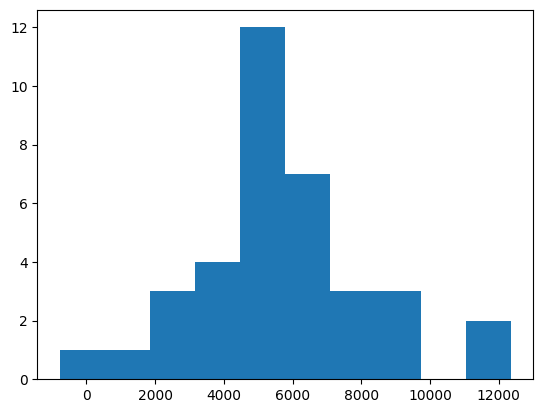

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm


# import the data with pandas
new_sales = pd.read_csv('amir_deals.csv')

# Calculate new average amount
new_mean = 5000 * 1.20
# print(new_mean)

# Calculate new standard deviation
new_sd = 2000 * 1.30

# Simulate 36 new sales
new_sales = norm.rvs(loc = new_mean, scale = new_sd, size = 36)

# Create histogram and show
plt.hist(new_sales)
plt.show()

### Simulating Data Under New Market Conditions

In this scenario, we are predicting future sales performance based on changing market conditions. The expected value (mean) of a deal is increasing by 20%, but the volatility (standard deviation) is also increasing by 30%. 

Here is the step-by-step approach to simulating this new data:

**1. Adjusting the Parameters**
First, we mathematically apply the market changes to our historical data:
* `new_mean`: We increase the historical $5000 average by 20% (multiplying by 1.20) to get a new mean of **$6000**.
* `new_sd`: We increase the historical $2000 standard deviation by 30% (multiplying by 1.30) to get a new standard deviation of **$2600**.

**2. Simulating the Sales (`norm.rvs`)**
We use the Random Variate Sample (`rvs`) function to simulate 36 distinct deals under these new rules. 
* *Best Practice:* We explicitly declare the parameter names (`loc=new_mean`, `scale=new_sd`, `size=36`) so Python does not confuse the order of the inputs.
* The output (`new_sales`) is a raw NumPy array containing 36 simulated dollar amounts.

**3. Visualizing the Results**
Finally, we pass that raw array directly into `plt.hist(new_sales)` to visualize the distribution of our simulated quarter. Because we increased both the mean and the standard deviation, the resulting bell curve will be shifted to the right (higher average deals) but will also look wider and flatter (more unpredictable deal sizes).

# Study Notes: The Central Limit Theorem (CLT)

**The Theorem:** The distribution of sample means will take the shape of a normal distribution (bell curve), regardless of the shape of the original population data, provided the sample size is large enough (usually $n \ge 30$).

**Why it is important:** It allows us to use the normal distribution (`scipy.stats.norm`) to estimate probabilities and make predictions about datasets that are messy, skewed, or completely unknown.

### Python Proof: Simulating the CLT

We can prove this by rolling a virtual 6-sided die. Single die rolls are uniform (flat). But if we roll 30 dice at a time and take their average, those averages will form a bell curve.

```python
import numpy as np
import matplotlib.pyplot as plt

# 1. The original messy data (Rolling 1 die, 1000 times)
# This will plot a flat, blocky histogram (Uniform)
single_rolls = np.random.randint(1, 7, size=1000)
plt.hist(single_rolls, bins=6)
plt.title("Original Data: 1 Roll (Uniform)")
plt.show()

# 2. Applying the Central Limit Theorem
sample_means = []

# Take 1000 different samples
for i in range(1000):
    # In each sample, roll 30 dice (n=30)
    sample = np.random.randint(1, 7, size=30)
    
    # Calculate the mean of those 30 rolls and save it
    sample_means.append(np.mean(sample))

# 3. Plotting the Sample Means
# This will plot a perfect Normal Distribution (Bell Curve!)
plt.hist(sample_means, bins=20)
plt.title("Sample Means (n=30) form a Normal Distribution")
plt.show()

# Study Notes: Central Limit Theorem in Python

The Central Limit Theorem (CLT) is implemented in Python by creating a `for` loop that repeatedly takes random samples from a dataset and records the mean of each sample. 

This process converts a messy, non-normal dataset into a clean, normally distributed array of averages (a bell curve).

### The 4-Step Process

1. **Create an empty list:** This is the "wall" where you will place all your sticky notes.
2. **Start a `for` loop:** Tell Python how many "handfuls" to grab (e.g., 1000 times).
3. **Take a sample:** Inside the loop, randomly select at least 30 items from your dataset.
4. **Calculate and append:** Find the mean of that sample and add it to your list.

---

### Example: Applying the CLT to Sales Data

Imagine `amir_deals` is a massive, chaotic dataset of tens of thousands of past sales of all different sizes. We want to find the distribution of his average performance based on a 30-deal sample.


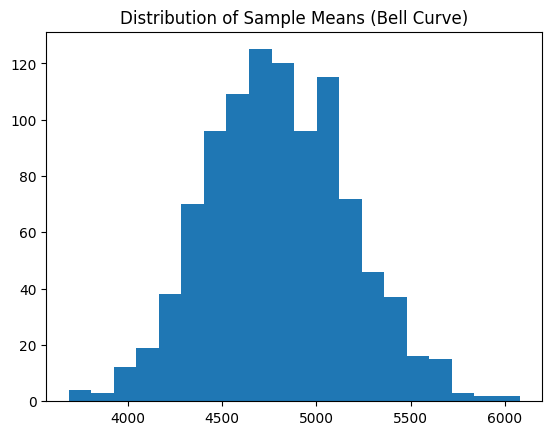

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

amir_deals = pd.read_csv('amir_deals.csv')

# 1. Create an empty list (The blank wall)
sample_means = []

# 2. Run the experiment 1,000 times
for i in range(1000):
    
    # 3. The "Handful": Grab 30 random deals from the dataset
    # (replace=True means we put the deals back in the jar after looking)
    sample = amir_deals['amount'].sample(n=30, replace=True)
    
    # 4. The "Sticky Note": Calculate the average of those 30 deals
    sample_mean = np.mean(sample)
    
    # Stick the average on the wall
    sample_means.append(sample_mean)

# --- The Magic Result ---
# 'sample_means' is now a list of 1,000 averages. 
# Thanks to the CLT, this data now forms a perfect Normal Distribution!

# We can prove it by looking at the histogram:
plt.hist(sample_means, bins=20)
plt.title("Distribution of Sample Means (Bell Curve)")
plt.show()

In [3]:
import numpy as np
import pandas as pd

all_deals = pd.read_csv('amir_deals.csv')


# Set seed to 321
np.random.seed(321)

sample_means = []
# Loop 30 times to take 30 means
for i in range(30):
  # Take sample of size 20 from num_users col of all_deals with replacement
  cur_sample = all_deals['num_users'].sample(20, replace = True)
  # Take mean of cur_sample
  cur_mean = cur_sample.mean()
  # Append cur_mean to sample_means
  sample_means.append(cur_mean)

# Print mean of sample_means
print(np.mean(sample_means))

# Print mean of num_users in amir_deals
print(np.mean(amir_deals['num_users']))

38.821666666666665
37.651685393258425


# Study Notes: The Poisson Distribution

The **Poisson Distribution** is used to calculate the probability of a specific number of events happening within a continuous, open window of time or space. 

* **The Key Difference:** Unlike the Binomial distribution (which has a strict maximum limit of trials), Poisson is an "open stopwatch." There is no physical maximum limit to how many events could theoretically happen.
* **Data Type:** Discrete (counting whole numbers of events, like 0, 1, 2, 3...).
* **The Parameter:** Lambda ($\lambda$). This is the historical **average rate** of events per time period.

### Python Implementation (`scipy.stats.poisson`)
In Python, the Lambda parameter ($\lambda$) is passed using the argument `mu` (which stands for mean).

**1. Exact Probabilities (`pmf`)**
Use the Probability Mass Function to find the chance of getting an *exact* number of events.
* *Scenario: Amir averages 5 lead emails per week ($\lambda = 5$). What is the probability he gets EXACTLY 4 emails this week?*
```python
from scipy.stats import poisson

# k = target count, mu = average rate (lambda)
prob_exactly_4 = poisson.pmf(k=4, mu=5)
```

### 2. Range Probabilities (`cdf`)
Use the Cumulative Distribution Function for "less than or equal to" ranges.

*Scenario: What is the probability Amir gets 3 OR FEWER emails this week?*
```python
# Everything up to and including 3
prob_3_or_fewer = poisson.cdf(k=3, mu=5)

# Pro-Tip: To find strictly "greater than", use the subtraction rule (1 - cdf).
# Probability of getting MORE THAN 3 emails:
prob_greater_than_3 = 1 - poisson.cdf(k=3, mu=5)
```

### 3. Simulating Data (`rvs`)
Use the Random Variate Sample function to simulate future windows of time based on the historical average.

*Scenario: Simulate the number of emails Amir will receive each week for the next 52 weeks.*
```python
from scipy.stats import poisson

# mu = average rate, size = number of simulations (weeks)
simulated_weeks = poisson.rvs(mu=5, size=52)
```

# Study Notes: The Exponential Distribution

The **Exponential Distribution** models the amount of time that passes *between* Poisson events. 
* **Data Type:** Continuous (time can be broken down into infinite decimals).
* **The Shape:** The curve starts at its peak on the far left (0 wait time) and slopes continuously downward to the right. This indicates that shorter wait times are highly common, while extremely long wait times are rare.

### The Parameter: Scale (Average Wait Time)
Unlike Poisson which uses Lambda (the *rate* of events), the exponential distribution uses the **average wait time** between events. 

* **The Rule of Inverses:** If you know the Poisson rate ($\lambda$), you can easily find the Exponential wait time. 
    * If Amir gets **2 calls per hour** ($\lambda = 2$)...
    * He waits an average of **$1/2$ an hour** between calls (Scale = 0.5 hours).

---

### Python Implementation (`scipy.stats.expon`)

In Python, the parameter for the average wait time is called `scale`. 

#### 1. Range Probabilities (`cdf`)
Use the Cumulative Distribution Function to find the probability of waiting *less than* a certain amount of time.
* *Scenario: Amir waits an average of 0.5 hours between calls. What is the probability he waits **less than 15 minutes** (0.25 hours) for the next call?*

```python
from scipy.stats import expon

# x = target time, scale = average wait time
prob_less_than_15m = expon.cdf(x=0.25, scale=0.5)
```

### 2. Greater-Than Probabilities ($1 - \text{cdf}$)
Subtract the CDF from 1 to find the probability of waiting *longer* than a certain amount of time.

*Scenario: What is the probability Amir waits **more than 1 hour** for the next call?*
```python
from scipy.stats import expon

# 1 minus everything up to 1 hour
prob_more_than_1hr = 1 - expon.cdf(x=1.0, scale=0.5)
```

### 3. Simulating Data (`rvs`)
Use the Random Variate Sample function to simulate future wait times based on the historical average.

*Scenario: Simulate the wait times for the next 10 inbound calls.*
```python
from scipy.stats import expon

# scale = average wait time, size = number of simulations
simulated_wait_times = expon.rvs(scale=0.5, size=10)

### What is the t-Distribution?
Also known as "Student's t-distribution," this is essentially the Normal Distribution’s highly cautious younger sibling. 

Earlier, we learned that because of the Central Limit Theorem, we can assume sample means form a perfect Normal Distribution... *as long as we have a large sample size (usually 30 or more).*

But what happens if Amir only has **5 sales** to look at this month? We do not have enough data to be perfectly confident. This is where the t-distribution steps in. It is shaped like a bell curve, but it has **"fatter tails."** This extra thickness on the edges mathematically accounts for the uncertainty of having a small amount of data, making extreme outcomes slightly more probable.

### The Magic Parameter: Degrees of Freedom (df)
The t-distribution has a unique parameter called **Degrees of Freedom (`df`)**, which is directly tied to your sample size. 
* The formula is simply: **Sample Size minus 1** ($df = n - 1$).
* If Amir has 5 sales, his Degrees of Freedom is 4.

**The Golden Rule of the t-Distribution:** As your sample size grows larger, your uncertainty vanishes. Once your Degrees of Freedom hits about 30, the t-distribution becomes indistinguishable from a perfect Normal Distribution!

The **t-Distribution** is used instead of the Normal distribution when calculating probabilities or confidence intervals with a **small sample size** (typically $n < 30$) or when the population standard deviation is unknown.

* **The Shape:** It is a bell curve, but it has "fatter tails" than the normal distribution. This accounts for the increased uncertainty of having less data.
* **The Parameter:** Degrees of Freedom (`df`). 
    * Calculated as sample size minus one ($df = n - 1$).
    * As `df` increases, the t-distribution converges to look exactly like the Normal distribution.

### Python Implementation (`scipy.stats.t`)

The functions behave exactly like `norm`, but you must pass the mandatory `df` parameter!

#### 1. Range Probabilities (`cdf`)
Use the Cumulative Distribution Function for "less than" probabilities.
* *Scenario: Amir has a small sample of 5 recent deals ($df = 4$). The sample mean is $5000, and the sample standard deviation is $2000. What is the probability a deal from this environment is less than $4000?*

```python
from scipy.stats import t

# x = target, df = degrees of freedom (n-1), loc = mean, scale = std dev
prob_less_than_4000 = t.cdf(x=4000, df=4, loc=5000, scale=2000)

# Study Notes: Correlation

**Correlation** measures the strength and direction of the linear relationship between two numerical variables.
* **The Metric:** Pearson's Correlation Coefficient ($r$).
* **The Range:** Between -1.0 (perfect negative) and 1.0 (perfect positive). A value of 0 means no linear relationship.
* **The Golden Rule:** Correlation does **not** imply causation. Just because two variables move together does not mean one is physically causing the other to happen.

---

### 1. Visualizing Correlation (Scatter Plots)
Before calculating the math, you should always visualize your data using a scatter plot to ensure the relationship is actually a straight line (and not a curved/quadratic shape). We use the `seaborn` library for this.

*Scenario: Plot Amir's `deal_size` on the x-axis and his `time_spent` on the y-axis.*

```python
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a scatter plot with a trendline (line of best fit)
sns.lmplot(x='deal_size', y='time_spent', data=amir_deals)

plt.title("Relationship between Deal Size and Time Spent")
plt.show()
```

### 2. Calculating Correlation ($r$) in Pandas
You do not need `scipy` for basic correlation; it is built directly into Pandas DataFrames!

*Scenario: Calculate the exact $r$ value between `deal_size` and `time_spent`.*
```python
# Use the .corr() method on a specific column, passing the second column as the argument
r_value = amir_deals['deal_size'].corr(amir_deals['time_spent'])

print(r_value)
```

### 3. Exploring a Whole Dataset (Correlation Matrices)
If you have a massive dataset and want to see how *every* number relates to *every other* number, you can run `.corr()` on the entire DataFrame.

```python
# This generates a grid/table showing the r-value for every possible pair of columns
correlation_matrix = amir_deals.corr()

print(correlation_matrix)
```

### Exploring the Relationship: Life Expectancy vs. Happiness

To truly understand how two variables relate, it is a data science best practice to evaluate them both visually and quantitatively. 

* **Visually (`sns.lmplot`):** Draws the scatterplot and the line of best fit to help us see the direction and shape of the relationship. We set `ci=None` to remove the confidence interval shading for a cleaner look.
* **Quantitatively (`.corr()`):** Calculates the exact Pearson correlation coefficient ($r$) to tell us exactly how strong that relationship is.


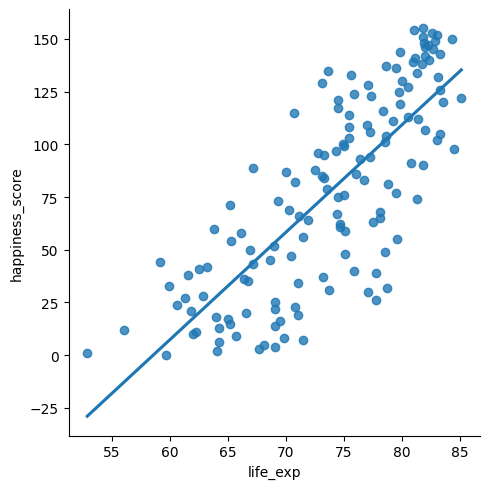

Correlation Coefficient (r): 0.7802249053272062


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

world_happiness = pd.read_csv('world_happiness.csv')

# 1. VISUALIZE: Create a scatterplot with a trendline
sns.lmplot(x='life_exp', y='happiness_score', data=world_happiness, ci=None)

# Show the plot
plt.show()

# 2. QUANTIFY: Calculate the exact correlation coefficient (r)
cor = world_happiness['life_exp'].corr(world_happiness['happiness_score'])

# Print the result
print("Correlation Coefficient (r):", cor)

# Study Notes: The Caveats of Correlation

Pearson’s correlation coefficient ($r$) is a powerful metric, but it can be highly misleading if you do not visually inspect your data first. There are three major traps to watch out for:

### 1. The Non-Linear Trap
Pearson’s $r$ is strictly programmed to measure **straight lines**. If your data has a perfect, clear relationship that happens to be curved (like a U-shape or an exponential curve), the math will fail to see it and might return an $r$ value of 0. 

### 2. The Outlier Effect
Because the calculation measures the average distance of points from a line, **a single extreme outlier can hijack the entire calculation.** One massive, weird data point can take a completely random dataset and trick the formula into returning a strong correlation.

### 3. Correlation $\neq$ Causation
This is the Golden Rule of statistics. Just because two variables move together in a straight line does **not** mean one causes the other to happen. Often, they are both simply reacting to a hidden third variable (known as a *spurious correlation*).

# Study Notes: Correlation Caveats Defence

Pearson's correlation coefficient ($r$) can be highly misleading. It only measures *linear* relationships, and it is highly sensitive to extreme outliers. 

### Defense 1: Always Plot First
Never calculate `.corr()` without looking at the data first. If the data is curved or has extreme outliers, the $r$ value is lying to you.

```python
import seaborn as sns
import matplotlib.pyplot as plt

# Always draw the lmplot to physically see the shape of the data
sns.lmplot(x='advertising_budget', y='sales', data=company_data, ci=None)
plt.show()
```

### Defense 2: Log Transformation (Fixing Curves)
If your scatterplot reveals a curve (often caused by data that grows exponentially, like money or population), Pearson's $r$ will be inaccurate. 

You can "un-curve" the data by applying a **Log Transformation**. This squishes the extreme high values closer together, often straightening the curve into a line so you can accurately measure it.

*Scenario: `sales` is growing exponentially compared to `advertising_budget`. We need to log-transform `sales` before calculating correlation.*

```python
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a new column with the log-transformed data
company_data['log_sales'] = np.log(company_data['sales'])

# 2. Check the new straight-line relationship visually
sns.lmplot(x='advertising_budget', y='log_sales', data=company_data, ci=None)
plt.show()

# 3. Calculate the newly accurate correlation coefficient
accurate_r = company_data['advertising_budget'].corr(company_data['log_sales'])
print(accurate_r)
```

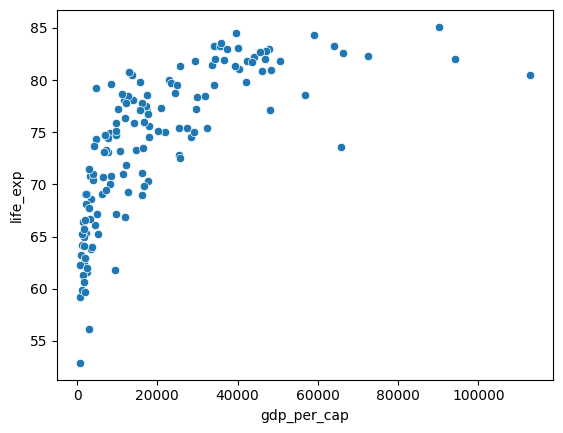

0.7019547642148015


In [ ]:
# Python Implementation

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

world_happiness = pd.read_csv('world_happiness.csv')

# Scatterplot of gdp_per_cap and life_exp
sns.scatterplot(x='gdp_per_cap', y='life_exp', data=world_happiness)

# Show plot
plt.show()
  
# Correlation between gdp_per_cap and life_exp
cor = world_happiness['gdp_per_cap'].corr(world_happiness['life_exp'])

print(cor)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the log_gdp_per_cap column
world_happiness['log_gdp_per_cap'] = np.log(world_happiness['gdp_per_cap'])

# 2. Scatterplot of happiness_score vs. log_gdp_per_cap
sns.scatterplot(x='log_gdp_per_cap', y='happiness_score', data=world_happiness)
plt.title("Happiness Score vs. Log GDP per Capita")
plt.show()

# 3. Calculate correlation
cor = world_happiness['log_gdp_per_cap'].corr(world_happiness['happiness_score'])
print("Correlation Coefficient (r):", cor)




# Study Notes: Design of Experiments

To prove **causation** (that X causes Y), you cannot rely on observational data. You must design a controlled experiment. 

### 1. The Two Types of Studies
* **Observational Study:** Data is collected as it naturally exists (e.g., surveys, historical databases). 
    * *Result:* Can only prove **Correlation**. Highly vulnerable to confounders.
* **Experiment:** The researcher actively applies a treatment to subjects and observes the response.
    * *Result:* The only way to prove **Causation**.

### 2. Anatomy of a Good Experiment
A "Randomized Controlled Trial" (RCT) is the gold standard of data science and medical research. It requires:
* **Treatment Group:** The subjects who receive the intervention, feature, or drug being tested.
* **Control Group:** The subjects who receive a placebo, or standard procedure. They act as the baseline.
* **Random Assignment:** Subjects are sorted into the Treatment or Control group completely by chance (like a coin flip). 
    * *Why it matters:* Randomization ensures that any hidden confounders (like age, health, or income) are evenly distributed between both groups. It makes the two groups perfectly identical, except for the treatment itself.

### 3. Protecting Against Bias
Even in an experiment, human psychology can ruin the data.
* **Blind Experiment:** The subjects do not know if they are in the Treatment or Control group (prevents the placebo effect).
* **Double-Blind Experiment:** Neither the subjects *nor the researchers* know who is in which group until the experiment is over (prevents the researcher from accidentally treating the groups differently).

# Study Notes: Cross-Sectional vs. Longitudinal Data

The way data is collected changes how it must be structured and analyzed in a Pandas DataFrame.

### 1. Cross-Sectional Data (Wide Format)
Because every subject is only measured once, there is exactly **one row per subject**.

```python
import pandas as pd

# Example: A snapshot of 3 customers in 2026
cross_sec_data = {
    'customer_id': [1, 2, 3],
    'age': [25, 42, 35],
    'total_spent': [150, 400, 250]
}
df_cross = pd.DataFrame(cross_sec_data)

# You can easily calculate standard correlations here
correlation = df_cross['age'].corr(df_cross['total_spent'])
```

### 2. Longitudinal Data (Long Format)
Because the exact same subjects are measured multiple times, there are **multiple rows per subject**. You must have a column that tracks time (like Year or Date).

```python
import pandas as pd

# Example: Tracking the exact same 2 customers over 3 years
longitudinal_data = {
    'customer_id': [1, 1, 1, 2, 2, 2],
    'year': [2024, 2025, 2026, 2024, 2025, 2026],
    'total_spent': [100, 150, 180, 300, 400, 380]
}
df_long = pd.DataFrame(longitudinal_data)
```

### 3. Analyzing Longitudinal Data (`groupby`)
You cannot run a standard correlation on Longitudinal data because the rows are not independent (Customer 1's spending in 2025 is directly related to Customer 1's spending in 2024). 

Instead, you use `.groupby()` to calculate metrics for each specific individual over time.

```python
# Calculate the average spending for each specific customer across all years
average_spend_per_person = df_long.groupby('customer_id')['total_spent'].mean()

print(average_spend_per_person)
```